# Processing of a resting-state EEG dataset for sleep deprivation

Bad channels are interpolated

## PRE PROCESSING

#### The intention is to provide epochs(4 seconds) to the machine and try predicting if the case is sleep deprivation or normal sleep.

In [1]:
from matplotlib import pyplot as plt
import os
import pandas as pd
import numpy as np
from scipy import signal
import mne
import mne_icalabel
from mne.preprocessing import ICA
from autoreject import Ransac  
from mne_icalabel import label_components
%matplotlib inline

In [2]:
# lists to collect data
X_train_list = []
y_train_list = []
X_test_list = []
y_test_list = []

In [3]:
n_epochs = 0
for i in range(1, 72):
    if i == 28 or i== 1 or i== 44 or i==39 or i==43 or i in [7,8,11,13,18,24,29,31,35,36,37,38,40,47,48,50,54,58,59,63,67,70,71]:
        continue  # Skip participant 1,28 due to missing data
    for j in range(1, 3):
        
        #Define file path
        file_path = f'D:\\BCI\\TASKS\\Task-8\\ds004902_data\\sub-{i:02d}\\ses-{j}\\eeg\\sub-{i:02d}_ses-{j}_task-eyesopen_eeg.set'#The d indicates that the value is a decimal integer, while the 02 specifies that the output should be padded with leading zeros if necessary to reach a width of two characters.
        epochs_file = f'D:\\BCI\\TASKS\\Task-8\\processed_epochs_60\\sub-{i:02d}_ses-{j}_epochs.fif'  # Path to save/load processed epochs
        
        
        if os.path.exists(epochs_file):
            print(f"Loading processed epochs from {epochs_file}")
            epochs = mne.read_epochs(epochs_file, preload=True)
        else:
            print(f"\nProcessing: {file_path}\n")

            #Define EEG channels
            eeg_channels = ["Fp1", "AF3", "AF7", "Fz", "F1", "F3", "F5", "F7","FC1", "FC3", "FC5", "FT7","Cz", "C1", "C3", "C5", "T7","CP1", "CP3", "CP5", "TP7", "TP9","Pz", "P1", "P3", "P5", "P7","PO3", "PO7", "Oz", "O1","Fpz", "Fp2", "AF4", "AF8","F2", "F4", "F6", "F8","FC2", "FC4", "FC6", "FT8","C2", "C4", "C6", "T8","CPz", "CP2", "CP4", "CP6","TP8", "TP10","P2", "P4", "P6", "P8","POz", "PO4", "PO8", "O2"]
            
            #Load EEG data
            raw = mne.io.read_raw_eeglab(file_path, preload=True)
            eeg_raw=raw.pick(mne.pick_channels(raw.info['ch_names'], include=eeg_channels))
            
            #Montage setting
            montage = mne.channels.make_standard_montage('standard_1020')
            eeg_raw.set_montage(montage)

            #Filtering
            eeg_raw.filter(1., 40.)#, fir_design='firwin')

            #Average Referencing
            eeg_raw.set_eeg_reference('average', projection=False)

            #EPOCHING
            epochs = mne.make_fixed_length_epochs(eeg_raw, duration=4.0, overlap=0.0,preload=True)

            #RANSAC for bad channel detection
            ransac = Ransac(verbose=False, n_jobs=1)
            ransac.fit(epochs)
            epochs.info['bads'].extend(ransac.bad_chs_)   

            #interpolate bad channels
            epochs.interpolate_bads(reset_bads=True)
            
            #ICA for artifact removal
            ica = mne.preprocessing.ICA(n_components=20, method='infomax', fit_params=dict(extended=True), random_state=42, max_iter=1000)
            ica.fit(epochs)

            ic_labels = label_components(epochs, ica, method='iclabel')
            exclude_idx = []
            for idx, label in enumerate(ic_labels["labels"]):
                if label not in ["brain","other","muscle artifact"] and ic_labels["y_pred_proba"][idx] > 0.5:
                    exclude_idx.append(idx)

            ica.apply(epochs,exclude= exclude_idx)        

            # Save processed epochs
            os.makedirs(os.path.dirname(epochs_file), exist_ok=True) #creates the necessary directories for the file path if they don't exist.
            epochs.save(epochs_file, overwrite=True)
            print(f"Saved processed epochs to {epochs_file}")

        if j==1:
            labels = 0
        elif j==2:
            labels = 1
        labels = pd.DataFrame({'label': [labels]*len(epochs)})
        
        # Extract data and labels
        data = epochs.get_data()  # shape: (n_epochs, n_channels, n_times)

        if (i == 39 or i == 43) and j == 2:
            data = signal.decimate(data, 10, axis=2) # Downsample by a factor of 10 to match time points.

        epoch_labels = labels['label'].values  
        
        if i <= 56:  # Training data
            X_train_list.append(data)
            y_train_list.append(epoch_labels)
        else:  # Testing data
            X_test_list.append(data)
            y_test_list.append(epoch_labels)

# After the loop, concatenate into arrays
X_train = np.concatenate(X_train_list, axis=0)
y_train = np.concatenate(y_train_list, axis=0)
X_test = np.concatenate(X_test_list, axis=0)
y_test = np.concatenate(y_test_list, axis=0)
print("Training and testing data processing complete")

Loading processed epochs from D:\BCI\TASKS\Task-8\processed_epochs_60\sub-02_ses-1_epochs.fif
Reading D:\BCI\TASKS\Task-8\processed_epochs_60\sub-02_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated


C:\Users\suvan\AppData\Local\Temp\ipykernel_7684\3365013450.py:14: RuntimeWarning: This filename (D:\BCI\TASKS\Task-8\processed_epochs_60\sub-02_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


Loading processed epochs from D:\BCI\TASKS\Task-8\processed_epochs_60\sub-02_ses-2_epochs.fif
Reading D:\BCI\TASKS\Task-8\processed_epochs_60\sub-02_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found


C:\Users\suvan\AppData\Local\Temp\ipykernel_7684\3365013450.py:14: RuntimeWarning: This filename (D:\BCI\TASKS\Task-8\processed_epochs_60\sub-02_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


No baseline correction applied
0 projection items activated
Loading processed epochs from D:\BCI\TASKS\Task-8\processed_epochs_60\sub-03_ses-1_epochs.fif
Reading D:\BCI\TASKS\Task-8\processed_epochs_60\sub-03_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated


...

Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:\BCI\TASKS\Task-8\processed_epochs_60\sub-68_ses-2_epochs.fif
Reading D:\BCI\TASKS\Task-8\processed_epochs_60\sub-68_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:\BCI\TASKS\Task-8\processed_epochs_60\sub-69_ses-1_epochs.fif
Reading D:\BCI\TASKS\Task-8\processed_epochs_60\sub-69_ses-1_epochs.fif ...


C:\Users\suvan\AppData\Local\Temp\ipykernel_7684\3365013450.py:14: RuntimeWarning: This filename (D:\BCI\TASKS\Task-8\processed_epochs_60\sub-68_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\suvan\AppData\Local\Temp\ipykernel_7684\3365013450.py:14: RuntimeWarning: This filename (D:\BCI\TASKS\Task-8\processed_epochs_60\sub-69_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:\BCI\TASKS\Task-8\processed_epochs_60\sub-69_ses-2_epochs.fif
Reading D:\BCI\TASKS\Task-8\processed_epochs_60\sub-69_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated


C:\Users\suvan\AppData\Local\Temp\ipykernel_7684\3365013450.py:14: RuntimeWarning: This filename (D:\BCI\TASKS\Task-8\processed_epochs_60\sub-69_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


Training and testing data processing complete


In [4]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((339, 61, 30000), (339,), (85, 61, 30000), (85,))

In [5]:
X_train

array([[[-1.86939514e-09, -1.33587992e-06, -2.67785286e-06, ...,
          3.39845633e-06,  2.90296911e-06,  2.38385891e-06],
        [-1.94064725e-09,  1.98257356e-07,  1.31205871e-07, ...,
          6.59083508e-06,  6.43760393e-06,  6.10524176e-06],
        [-1.08360790e-09, -6.29877148e-07, -1.39925456e-06, ...,
          2.80599474e-06,  2.63128828e-06,  2.36371660e-06],
        ...,
        [ 4.23254502e-10,  1.06595909e-06,  2.29082608e-06, ...,
          1.41882562e-06,  2.76843046e-06,  3.73536276e-06],
        [ 4.71726466e-10,  2.87471890e-07,  8.53711305e-07, ...,
          1.00523967e-05,  1.02179270e-05,  9.79988763e-06],
        [ 5.23308931e-10,  1.85923862e-06,  3.72308849e-06, ...,
          3.99468016e-06,  6.16059874e-06,  7.70940350e-06]],

       [[ 1.86271786e-06,  1.33896160e-06,  7.96520708e-07, ...,
         -9.06401095e-07, -8.24688671e-08,  6.52927635e-07],
        [ 5.61213015e-06,  4.99401473e-06,  4.29776095e-06, ...,
         -4.90488957e-06, -4.45498608e

## FEATURE EXTRACTION 

In [6]:
from scipy import stats

In [7]:
# Frequency-domain feature extraction functions
def bandpower_delta(sample_data, fs=500, axis=-1):
    freqs, psd_values = signal.welch(sample_data, fs=fs, axis=axis)
    delta_band = (0.5, 4)
    mask = (freqs >= delta_band[0]) & (freqs <= delta_band[1])
    delta_power = np.trapezoid(psd_values[..., mask], freqs[mask], axis=axis)
    return delta_power

def bandpower_theta(sample_data, fs=500, axis=-1):


    
    freqs, psd_values = signal.welch(sample_data, fs=fs, axis=axis)
    theta_band = (4, 8)
    mask = (freqs >= theta_band[0]) & (freqs <= theta_band[1])
    theta_power = np.trapezoid(psd_values[..., mask], freqs[mask], axis=axis)
    return theta_power

def bandpower_alpha(sample_data, fs=500, axis=-1):
    freqs, psd_values = signal.welch(sample_data, fs=fs, axis=axis)
    alpha_band = (8, 13)
    mask = (freqs >= alpha_band[0]) & (freqs <= alpha_band[1])
    alpha_power = np.trapezoid(psd_values[..., mask], freqs[mask], axis=axis)
    return alpha_power  

def bandpower_beta(sample_data, fs=500, axis=-1):
    freqs, psd_values = signal.welch(sample_data, fs=fs, axis=axis)
    beta_band = (13, 30)
    mask = (freqs >= beta_band[0]) & (freqs <= beta_band[1])
    beta_power = np.trapezoid(psd_values[..., mask], freqs[mask], axis=axis)
    return beta_power       

def bandpower_gamma(sample_data, fs=500, axis=-1):
    freqs, psd_values = signal.welch(sample_data, fs=fs, axis=axis)
    gamma_band = (30, 40)
    mask = (freqs >= gamma_band[0]) & (freqs <= gamma_band[1])
    gamma_power = np.trapezoid(psd_values[..., mask], freqs[mask], axis=axis)
    return gamma_power

def bandpower_total(sample_data, fs=500, axis=-1):
    freqs, psd_values = signal.welch(sample_data, fs=fs, axis=axis)
    total_band = (0.5, 40)
    mask = (freqs >= total_band[0]) & (freqs <= total_band[1])
    total_power = np.trapezoid(psd_values[..., mask], freqs[mask], axis=axis)
    return total_power

In [8]:
from tqdm import tqdm_notebook
delta_X_train_features=[]
for datta in tqdm_notebook(X_train):
    delta_features = bandpower_delta(datta)
    delta_X_train_features.append(delta_features)

delta_X_train_features=np.array(delta_X_train_features)
delta_X_train_features.shape

C:\Users\suvan\AppData\Local\Temp\ipykernel_7684\1244159739.py:3: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for datta in tqdm_notebook(X_train):


  0%|          | 0/339 [00:00<?, ?it/s]

(339, 61)

In [9]:
from tqdm.notebook import tqdm
delta_X_test_features=[]
for datta in tqdm (X_test):
    delta_features = bandpower_delta(datta)
    delta_X_test_features.append(delta_features)

delta_X_test_features=np.array(delta_X_test_features)
delta_X_test_features.shape

  0%|          | 0/85 [00:00<?, ?it/s]

(85, 61)

In [10]:
from tqdm.notebook import tqdm
theta_X_train_features=[]
for datta in tqdm(X_train):
    theta_features = bandpower_theta(datta)
    theta_X_train_features.append(theta_features)

theta_X_train_features=np.array(theta_X_train_features)
theta_X_train_features.shape

  0%|          | 0/339 [00:00<?, ?it/s]

(339, 61)

In [11]:
from tqdm.notebook import tqdm
theta_X_test_features=[]
for datta in tqdm(X_test):
    theta_features = bandpower_theta(datta)
    theta_X_test_features.append(theta_features)

theta_X_test_features=np.array(theta_X_test_features)
theta_X_test_features.shape

  0%|          | 0/85 [00:00<?, ?it/s]

(85, 61)

In [12]:
from tqdm.notebook import tqdm
alpha_X_train_features=[]
for datta in tqdm(X_train):
    alpha_features = bandpower_alpha(datta)
    alpha_X_train_features.append(alpha_features)

alpha_X_train_features=np.array(alpha_X_train_features)
alpha_X_train_features.shape

  0%|          | 0/339 [00:00<?, ?it/s]

(339, 61)

In [13]:
from tqdm.notebook import tqdm
alpha_X_test_features=[]
for datta in tqdm(X_test):
    alpha_features = bandpower_alpha(datta)
    alpha_X_test_features.append(alpha_features)

alpha_X_test_features=np.array(alpha_X_test_features)
alpha_X_test_features.shape

  0%|          | 0/85 [00:00<?, ?it/s]

(85, 61)

In [14]:
from tqdm.notebook import tqdm
beta_X_train_features=[]
for datta in tqdm(X_train):
    beta_features = bandpower_beta(datta)
    beta_X_train_features.append(beta_features)

beta_X_train_features=np.array(beta_X_train_features)
beta_X_train_features.shape

  0%|          | 0/339 [00:00<?, ?it/s]

(339, 61)

In [15]:
from tqdm.notebook import tqdm
beta_X_test_features=[]
for datta in tqdm(X_test):
    beta_features = bandpower_beta(datta)
    beta_X_test_features.append(beta_features)

beta_X_test_features=np.array(beta_X_test_features)
beta_X_test_features.shape

  0%|          | 0/85 [00:00<?, ?it/s]

(85, 61)

In [16]:
from tqdm.notebook import tqdm
gamma_X_train_features=[]
for datta in tqdm(X_train):
    gamma_features = bandpower_gamma(datta)
    gamma_X_train_features.append(gamma_features)

gamma_X_train_features=np.array(gamma_X_train_features)
gamma_X_train_features.shape

  0%|          | 0/339 [00:00<?, ?it/s]

(339, 61)

In [17]:
from tqdm.notebook import tqdm
gamma_X_test_features=[]
for datta in tqdm(X_test):
    gamma_features = bandpower_gamma(datta)
    gamma_X_test_features.append(gamma_features)

gamma_X_test_features=np.array(gamma_X_test_features)
gamma_X_test_features.shape

  0%|          | 0/85 [00:00<?, ?it/s]

(85, 61)

In [18]:
from tqdm.notebook import tqdm
total_X_train_features=[]
for datta in tqdm(X_train):
    total_features = bandpower_total(datta)
    total_X_train_features.append(total_features)

total_X_train_features=np.array(total_X_train_features)
total_X_train_features.shape

  0%|          | 0/339 [00:00<?, ?it/s]

(339, 61)

In [19]:
from tqdm.notebook import tqdm
total_X_test_features=[]
for datta in tqdm(X_test):
    total_features = bandpower_total(datta)
    total_X_test_features.append(total_features)

total_X_test_features=np.array(total_X_test_features)
total_X_test_features.shape

  0%|          | 0/85 [00:00<?, ?it/s]

(85, 61)

In [20]:
def feature_concatination(sample_data):
    feature_vector = []
    
    feature_vector.append(bandpower_delta(sample_data))
    feature_vector.append(bandpower_theta(sample_data))
    feature_vector.append(bandpower_alpha(sample_data))
    feature_vector.append(bandpower_beta(sample_data))
    feature_vector.append(bandpower_gamma(sample_data))
    
    
    return np.concatenate(feature_vector, axis=-1)

In [21]:
from tqdm import tqdm_notebook
X_train_features=[]
for datta in tqdm_notebook(X_train):
    features = feature_concatination(datta)
    X_train_features.append(features)

X_train_features=np.array(X_train_features)
X_train_features.shape

C:\Users\suvan\AppData\Local\Temp\ipykernel_7684\1365453675.py:3: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for datta in tqdm_notebook(X_train):


  0%|          | 0/339 [00:00<?, ?it/s]

(339, 305)

In [22]:
from tqdm import tqdm_notebook
X_test_features=[]
for datta in tqdm_notebook(X_test):
    features = feature_concatination(datta)
    X_test_features.append(features)

X_test_features=np.array(X_test_features)
X_test_features.shape  

C:\Users\suvan\AppData\Local\Temp\ipykernel_7684\3865815877.py:3: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for datta in tqdm_notebook(X_test):


  0%|          | 0/85 [00:00<?, ?it/s]

(85, 305)

## MACHINE LEARNING

#### Random Forest

In [23]:
from sklearn.ensemble import RandomForestClassifier

In [24]:
# Instantiate model with 1000 decision trees
rf = RandomForestClassifier(n_estimators = 1000, random_state = 42)
# Train the model on training data
rf.fit(delta_X_train_features, y_train)

RandomForestClassifier(n_estimators=1000, random_state=42)

In [25]:
predictions = rf.predict(delta_X_test_features)

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report
cm = confusion_matrix(y_test, predictions)
print("Confusion Matrix:\n", cm)
print("\n")
cf = classification_report(y_test, predictions)
print("Classification Report:\n", cf)
print("\n")
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Confusion Matrix:
 [[25 19]
 [13 28]]


Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.57      0.61        44
           1       0.60      0.68      0.64        41

    accuracy                           0.62        85
   macro avg       0.63      0.63      0.62        85
weighted avg       0.63      0.62      0.62        85



Accuracy: 0.6235294117647059


In [27]:
# Instantiate model with 1000 decision trees
rf = RandomForestClassifier(n_estimators = 1000, random_state = 42)
# Train the model on training data
rf.fit(theta_X_train_features, y_train)

RandomForestClassifier(n_estimators=1000, random_state=42)

In [28]:
predictions = rf.predict(theta_X_test_features)

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report
cm = confusion_matrix(y_test, predictions)
print("Confusion Matrix:\n", cm)
print("\n")
cf = classification_report(y_test, predictions)
print("Classification Report:\n", cf)
print("\n")
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Confusion Matrix:
 [[14 30]
 [ 7 34]]


Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.32      0.43        44
           1       0.53      0.83      0.65        41

    accuracy                           0.56        85
   macro avg       0.60      0.57      0.54        85
weighted avg       0.60      0.56      0.54        85



Accuracy: 0.5647058823529412


In [30]:
# Instantiate model with 1000 decision trees
rf = RandomForestClassifier(n_estimators = 1000, random_state = 42)
# Train the model on training data
rf.fit(alpha_X_train_features, y_train)

RandomForestClassifier(n_estimators=1000, random_state=42)

In [31]:
predictions = rf.predict(alpha_X_test_features)

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report
cm = confusion_matrix(y_test, predictions)
print("Confusion Matrix:\n", cm)
print("\n")
cf = classification_report(y_test, predictions)
print("Classification Report:\n", cf)
print("\n")
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Confusion Matrix:
 [[20 24]
 [ 9 32]]


Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.45      0.55        44
           1       0.57      0.78      0.66        41

    accuracy                           0.61        85
   macro avg       0.63      0.62      0.60        85
weighted avg       0.63      0.61      0.60        85



Accuracy: 0.611764705882353


In [33]:
# Instantiate model with 1000 decision trees
rf = RandomForestClassifier(n_estimators = 1000, random_state = 42)
# Train the model on training data
rf.fit(beta_X_train_features, y_train)

RandomForestClassifier(n_estimators=1000, random_state=42)

In [34]:
predictions = rf.predict(beta_X_test_features)

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report
cm = confusion_matrix(y_test, predictions)
print("Confusion Matrix:\n", cm)
print("\n")
cf = classification_report(y_test, predictions)
print("Classification Report:\n", cf)
print("\n")
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Confusion Matrix:
 [[23 21]
 [19 22]]


Classification Report:
               precision    recall  f1-score   support

           0       0.55      0.52      0.53        44
           1       0.51      0.54      0.52        41

    accuracy                           0.53        85
   macro avg       0.53      0.53      0.53        85
weighted avg       0.53      0.53      0.53        85



Accuracy: 0.5294117647058824


In [36]:
# Instantiate model with 1000 decision trees
rf = RandomForestClassifier(n_estimators = 1000, random_state = 42)
# Train the model on training data
rf.fit(gamma_X_train_features, y_train)

RandomForestClassifier(n_estimators=1000, random_state=42)

In [37]:
predictions = rf.predict(gamma_X_test_features)

In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report
cm = confusion_matrix(y_test, predictions)
print("Confusion Matrix:\n", cm)
print("\n")
cf = classification_report(y_test, predictions)
print("Classification Report:\n", cf)
print("\n")
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Confusion Matrix:
 [[31 13]
 [20 21]]


Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.70      0.65        44
           1       0.62      0.51      0.56        41

    accuracy                           0.61        85
   macro avg       0.61      0.61      0.61        85
weighted avg       0.61      0.61      0.61        85



Accuracy: 0.611764705882353


In [39]:
# Instantiate model with 1000 decision trees
rf = RandomForestClassifier(n_estimators = 1000, random_state = 42)
# Train the model on training data
rf.fit(total_X_train_features, y_train)

RandomForestClassifier(n_estimators=1000, random_state=42)

In [40]:
predictions = rf.predict(total_X_test_features)

In [41]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report
cm = confusion_matrix(y_test, predictions)
print("Confusion Matrix:\n", cm)
print("\n")
cf = classification_report(y_test, predictions)
print("Classification Report:\n", cf)
print("\n")
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Confusion Matrix:
 [[25 19]
 [10 31]]


Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.57      0.63        44
           1       0.62      0.76      0.68        41

    accuracy                           0.66        85
   macro avg       0.67      0.66      0.66        85
weighted avg       0.67      0.66      0.66        85



Accuracy: 0.6588235294117647


In [42]:
# Instantiate model with 1000 decision trees
rf = RandomForestClassifier(n_estimators = 1000, random_state = 42)
# Train the model on training data
rf.fit(X_train_features, y_train)

RandomForestClassifier(n_estimators=1000, random_state=42)

In [43]:
predictions = rf.predict(X_test_features)

In [44]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report
cm = confusion_matrix(y_test, predictions)
print("Confusion Matrix:\n", cm)
print("\n")
cf = classification_report(y_test, predictions)
print("Classification Report:\n", cf)
print("\n")
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Confusion Matrix:
 [[22 22]
 [11 30]]


Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.50      0.57        44
           1       0.58      0.73      0.65        41

    accuracy                           0.61        85
   macro avg       0.62      0.62      0.61        85
weighted avg       0.62      0.61      0.61        85



Accuracy: 0.611764705882353


##### SVM

In [45]:
from sklearn.svm import SVC

In [46]:
model = SVC(C=1.0, kernel='rbf', gamma='scale', random_state=42) #default parameters
model.fit(delta_X_train_features, y_train)

SVC(random_state=42)

In [47]:
predictions = model.predict(delta_X_test_features)

In [48]:
cm = confusion_matrix(y_test, predictions)
print("Confusion Matrix:\n", cm)
print
cf = classification_report(y_test, predictions)
print("Classification Report:\n", cf)
print("\n")
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Confusion Matrix:
 [[35  9]
 [25 16]]
Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.80      0.67        44
           1       0.64      0.39      0.48        41

    accuracy                           0.60        85
   macro avg       0.61      0.59      0.58        85
weighted avg       0.61      0.60      0.58        85



Accuracy: 0.6


In [49]:
model = SVC(C=1.0, kernel='rbf', gamma='scale', random_state=42) #default parameters
model.fit(theta_X_train_features, y_train)

SVC(random_state=42)

In [50]:
predictions = model.predict(theta_X_test_features)

In [51]:
cm = confusion_matrix(y_test, predictions)
print("Confusion Matrix:\n", cm)
print
cf = classification_report(y_test, predictions)
print("Classification Report:\n", cf)
print("\n")
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Confusion Matrix:
 [[31 13]
 [13 28]]
Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.70      0.70        44
           1       0.68      0.68      0.68        41

    accuracy                           0.69        85
   macro avg       0.69      0.69      0.69        85
weighted avg       0.69      0.69      0.69        85



Accuracy: 0.6941176470588235


In [52]:
model = SVC(C=1.0, kernel='rbf', gamma='scale', random_state=42) #default parameters
model.fit(alpha_X_train_features, y_train)

SVC(random_state=42)

In [53]:
predictions = model.predict(alpha_X_test_features)

In [54]:
cm = confusion_matrix(y_test, predictions)
print("Confusion Matrix:\n", cm)
print
cf = classification_report(y_test, predictions)
print("Classification Report:\n", cf)
print("\n")
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Confusion Matrix:
 [[25 19]
 [13 28]]
Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.57      0.61        44
           1       0.60      0.68      0.64        41

    accuracy                           0.62        85
   macro avg       0.63      0.63      0.62        85
weighted avg       0.63      0.62      0.62        85



Accuracy: 0.6235294117647059


In [55]:
model = SVC(C=1.0, kernel='rbf', gamma='scale', random_state=42) #default parameters
model.fit(beta_X_train_features, y_train)

SVC(random_state=42)

In [56]:
predictions = model.predict(beta_X_test_features)

In [57]:
cm = confusion_matrix(y_test, predictions)
print("Confusion Matrix:\n", cm)
print
cf = classification_report(y_test, predictions)
print("Classification Report:\n", cf)
print("\n")
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Confusion Matrix:
 [[30 14]
 [16 25]]
Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.68      0.67        44
           1       0.64      0.61      0.62        41

    accuracy                           0.65        85
   macro avg       0.65      0.65      0.65        85
weighted avg       0.65      0.65      0.65        85



Accuracy: 0.6470588235294118


In [58]:
model = SVC(C=1.0, kernel='rbf', gamma='scale', random_state=42) #default parameters
model.fit(gamma_X_train_features, y_train)

SVC(random_state=42)

In [59]:
predictions = model.predict(gamma_X_test_features)

In [60]:
cm = confusion_matrix(y_test, predictions)
print("Confusion Matrix:\n", cm)
print
cf = classification_report(y_test, predictions)
print("Classification Report:\n", cf)
print("\n")
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Confusion Matrix:
 [[28 16]
 [23 18]]
Classification Report:
               precision    recall  f1-score   support

           0       0.55      0.64      0.59        44
           1       0.53      0.44      0.48        41

    accuracy                           0.54        85
   macro avg       0.54      0.54      0.53        85
weighted avg       0.54      0.54      0.54        85



Accuracy: 0.5411764705882353


In [61]:
model = SVC(C=1.0, kernel='rbf', gamma='scale', random_state=42) #default parameters
model.fit(total_X_train_features, y_train)

SVC(random_state=42)

In [62]:
predictions = model.predict(total_X_test_features)

In [63]:
cm = confusion_matrix(y_test, predictions)
print("Confusion Matrix:\n", cm)
print
cf = classification_report(y_test, predictions)
print("Classification Report:\n", cf)
print("\n")
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Confusion Matrix:
 [[26 18]
 [13 28]]
Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.59      0.63        44
           1       0.61      0.68      0.64        41

    accuracy                           0.64        85
   macro avg       0.64      0.64      0.64        85
weighted avg       0.64      0.64      0.63        85



Accuracy: 0.6352941176470588


In [64]:
model = SVC(C=1.0, kernel='rbf', gamma='scale', random_state=42) #default parameters
model.fit(X_train_features, y_train)

SVC(random_state=42)

In [65]:
predictions = model.predict(X_test_features)

In [66]:
cm = confusion_matrix(y_test, predictions)
print("Confusion Matrix:\n", cm)
print
cf = classification_report(y_test, predictions)
print("Classification Report:\n", cf)
print("\n")
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Confusion Matrix:
 [[32 12]
 [18 23]]
Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.73      0.68        44
           1       0.66      0.56      0.61        41

    accuracy                           0.65        85
   macro avg       0.65      0.64      0.64        85
weighted avg       0.65      0.65      0.64        85



Accuracy: 0.6470588235294118


##### XG Boost

In [67]:
from xgboost import XGBClassifier

In [68]:
XGB = XGBClassifier(n_estimators=1000,learning_rate=0.05,max_depth=6,subsample=0.8,colsample_bytree=0.8,objective='binary:logistic',eval_metric='mlogloss',tree_method='auto')


In [69]:
XGB.fit(delta_X_train_features, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1000, n_jobs=None,
              num_parallel_tree=None, ...)

In [70]:
predictions = XGB.predict(delta_X_test_features)

In [71]:
cm = confusion_matrix(y_test, predictions)
print("Confusion Matrix:\n", cm)
print("\n")
cf = classification_report(y_test, predictions)
print("Classification Report:\n", cf)
print("\n")
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Confusion Matrix:
 [[16 28]
 [13 28]]


Classification Report:
               precision    recall  f1-score   support

           0       0.55      0.36      0.44        44
           1       0.50      0.68      0.58        41

    accuracy                           0.52        85
   macro avg       0.53      0.52      0.51        85
weighted avg       0.53      0.52      0.51        85



Accuracy: 0.5176470588235295


In [72]:
XGB.fit(theta_X_train_features, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1000, n_jobs=None,
              num_parallel_tree=None, ...)

In [73]:
predictions = XGB.predict(theta_X_test_features)

In [74]:
cm = confusion_matrix(y_test, predictions)
print("Confusion Matrix:\n", cm)
print("\n")
cf = classification_report(y_test, predictions)
print("Classification Report:\n", cf)
print("\n")
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Confusion Matrix:
 [[22 22]
 [10 31]]


Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.50      0.58        44
           1       0.58      0.76      0.66        41

    accuracy                           0.62        85
   macro avg       0.64      0.63      0.62        85
weighted avg       0.64      0.62      0.62        85



Accuracy: 0.6235294117647059


In [75]:
XGB.fit(alpha_X_train_features, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1000, n_jobs=None,
              num_parallel_tree=None, ...)

In [76]:
predictions = XGB.predict(alpha_X_test_features)

In [77]:
cm = confusion_matrix(y_test, predictions)
print("Confusion Matrix:\n", cm)
print("\n")
cf = classification_report(y_test, predictions)
print("Classification Report:\n", cf)
print("\n")
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Confusion Matrix:
 [[27 17]
 [ 8 33]]


Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.61      0.68        44
           1       0.66      0.80      0.73        41

    accuracy                           0.71        85
   macro avg       0.72      0.71      0.70        85
weighted avg       0.72      0.71      0.70        85



Accuracy: 0.7058823529411765


In [78]:
XGB.fit(beta_X_train_features, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1000, n_jobs=None,
              num_parallel_tree=None, ...)

In [79]:
predictions = XGB.predict(beta_X_test_features)

In [80]:
cm = confusion_matrix(y_test, predictions)
print("Confusion Matrix:\n", cm)
print("\n")
cf = classification_report(y_test, predictions)
print("Classification Report:\n", cf)
print("\n")
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Confusion Matrix:
 [[19 25]
 [14 27]]


Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.43      0.49        44
           1       0.52      0.66      0.58        41

    accuracy                           0.54        85
   macro avg       0.55      0.55      0.54        85
weighted avg       0.55      0.54      0.54        85



Accuracy: 0.5411764705882353


In [81]:
XGB.fit(gamma_X_train_features, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1000, n_jobs=None,
              num_parallel_tree=None, ...)

In [82]:
predictions = XGB.predict(gamma_X_test_features)

In [83]:
cm = confusion_matrix(y_test, predictions)
print("Confusion Matrix:\n", cm)
print("\n")
cf = classification_report(y_test, predictions)
print("Classification Report:\n", cf)
print("\n")
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Confusion Matrix:
 [[33 11]
 [20 21]]


Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.75      0.68        44
           1       0.66      0.51      0.58        41

    accuracy                           0.64        85
   macro avg       0.64      0.63      0.63        85
weighted avg       0.64      0.64      0.63        85



Accuracy: 0.6352941176470588


In [84]:
XGB.fit(total_X_train_features, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1000, n_jobs=None,
              num_parallel_tree=None, ...)

In [85]:
predictions = XGB.predict(total_X_test_features)

In [86]:
cm = confusion_matrix(y_test, predictions)
print("Confusion Matrix:\n", cm)
print("\n")
cf = classification_report(y_test, predictions)
print("Classification Report:\n", cf)
print("\n")
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Confusion Matrix:
 [[24 20]
 [12 29]]


Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.55      0.60        44
           1       0.59      0.71      0.64        41

    accuracy                           0.62        85
   macro avg       0.63      0.63      0.62        85
weighted avg       0.63      0.62      0.62        85



Accuracy: 0.6235294117647059


In [87]:
XGB.fit(X_train_features, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1000, n_jobs=None,
              num_parallel_tree=None, ...)

In [88]:
predictions = XGB.predict(X_test_features)

In [89]:
cm = confusion_matrix(y_test, predictions)
print("Confusion Matrix:\n", cm)
print("\n")
cf = classification_report(y_test, predictions)
print("Classification Report:\n", cf)
print("\n")
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Confusion Matrix:
 [[23 21]
 [11 30]]


Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.52      0.59        44
           1       0.59      0.73      0.65        41

    accuracy                           0.62        85
   macro avg       0.63      0.63      0.62        85
weighted avg       0.63      0.62      0.62        85



Accuracy: 0.6235294117647059


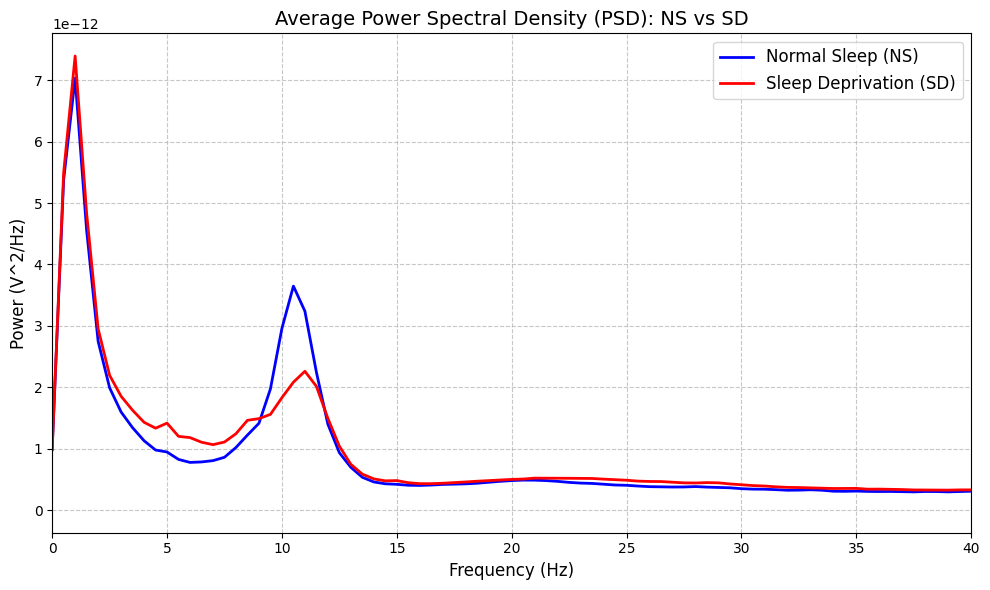

In [91]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

# 1. Combine Train and Test sets for a comprehensive plot
X_all = np.concatenate((X_train, X_test), axis=0)
y_all = np.concatenate((y_train, y_test), axis=0)

# 2. Separate the data by class
# Assuming label 0 = Normal Sleep (NS) and label 1 = Sleep Deprivation (SD)
X_NS = X_all[y_all == 0]
X_SD = X_all[y_all == 1]

# 3. Calculate PSD using Welch's method
# fs=500 because 60-second epochs with 30,000 samples = 500 Hz sampling rate
fs = 500 
freqs_NS, psd_NS = signal.welch(X_NS, fs=fs, axis=-1, nperseg=fs*2)
freqs_SD, psd_SD = signal.welch(X_SD, fs=fs, axis=-1, nperseg=fs*2)

# 4. Average the PSD across all epochs (axis=0) and all 61 channels (axis=0 of the remaining)
mean_psd_NS = np.mean(psd_NS, axis=(0, 1))
mean_psd_SD = np.mean(psd_SD, axis=(0, 1))

# 5. Plot the results
plt.figure(figsize=(10, 6))

# Plot both lines
plt.plot(freqs_NS, mean_psd_NS, label='Normal Sleep (NS)', color='blue', linewidth=2)
plt.plot(freqs_SD, mean_psd_SD, label='Sleep Deprivation (SD)', color='red', linewidth=2)

# Formatting the plot
plt.title('Average Power Spectral Density (PSD): NS vs SD', fontsize=14)
plt.xlabel('Frequency (Hz)', fontsize=12)
plt.ylabel('Power (V^2/Hz)', fontsize=12)

# Limit x-axis to 40 Hz since your data was filtered between 1 and 40 Hz
plt.xlim(0, 40) 

plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Display the plot
plt.show()